In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [9]:
from sklearn.model_selection import train_test_split
df = pd.read_csv("/Users/juberry/Documents/Code/Machine-Learning/Data/KNN/Instagram_visits_clustering.csv")
df.drop("User ID", axis=1, inplace=True)
df.info()

X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

<class 'pandas.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Instagram visit score    2600 non-null   int64  
 1   Spending_rank(0 to 100)  2600 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 40.8 KB
(2080, 2)
(520, 2)


In [10]:
print(df)

      Instagram visit score  Spending_rank(0 to 100)
0                        63                24.050708
1                        61                25.223290
2                       104                18.528245
3                        82                86.890232
4                        14                31.492397
...                     ...                      ...
2595                     25                25.745908
2596                     52                 9.275066
2597                    100                84.999487
2598                     87                20.530806
2599                     34                76.388622

[2600 rows x 2 columns]


In [11]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train)
print()
print(X_test)

[[0.31192661 0.15722062]
 [0.13761468 0.27377863]
 [0.28440367 0.62843825]
 ...
 [0.76146789 0.11633235]
 [0.09174312 0.29429   ]
 [0.59633028 0.18596784]]

[[0.44954128 0.11516439]
 [0.75229358 0.24082157]
 [0.78899083 0.76695113]
 ...
 [0.67889908 0.77945592]
 [0.22018349 0.20045605]
 [0.17431193 0.23979608]]


In [12]:
inertia = []
silhouette_scores = []

k_values = range(2, 11)
for k in k_values:
    k_means = KMeans(k, random_state=42)
    k_means.fit(X_train)
    inertia.append(k_means.inertia_)
    silhouette_scores.append(silhouette_score(X_train, k_means.labels_))

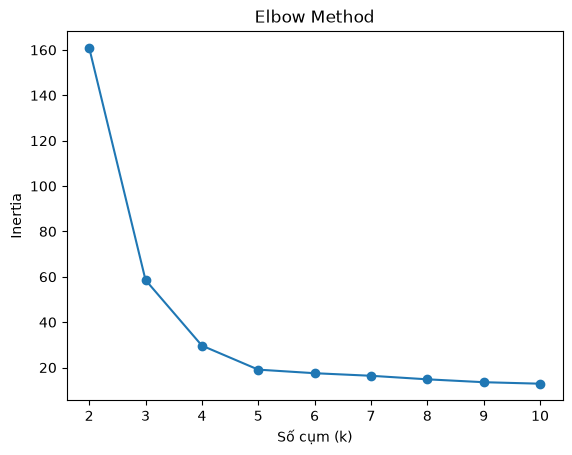

In [13]:
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Số cụm (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

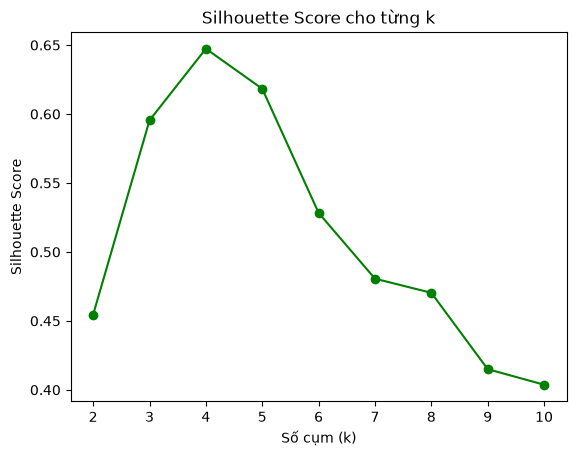

In [14]:
plt.plot(k_values, silhouette_scores, marker="o", color="green")
plt.xlabel("Số cụm (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score cho từng k")
plt.show()

In [15]:
optimal_k = k_values[np.argmax(silhouette_scores)]
print(optimal_k)
n = len(X_train)
print(n)

k_means_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=n)
cluster_labels = k_means_final.fit_predict(X_train)

silhouette_score(X_train, k_means.labels_)

4
2080


0.40371753306779584

In [16]:
predict = k_means_final.predict(X_test)
u_val = list(set(predict))

print(len(u_val))
print(u_val)

print("Prediction:", predict[:100])

4
[np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
Prediction: [3 0 2 2 2 2 2 3 3 0 1 0 0 2 0 2 3 0 3 0 0 0 2 0 0 3 3 3 1 2 2 0 0 3 0 0 1
 0 1 2 2 1 3 2 0 0 0 0 2 1 0 2 1 0 3 2 0 0 2 3 2 3 1 3 2 2 0 1 2 0 0 3 3 0
 0 1 2 0 0 0 0 1 0 2 3 0 0 0 3 3 2 2 1 0 3 2 1 2 1 0]


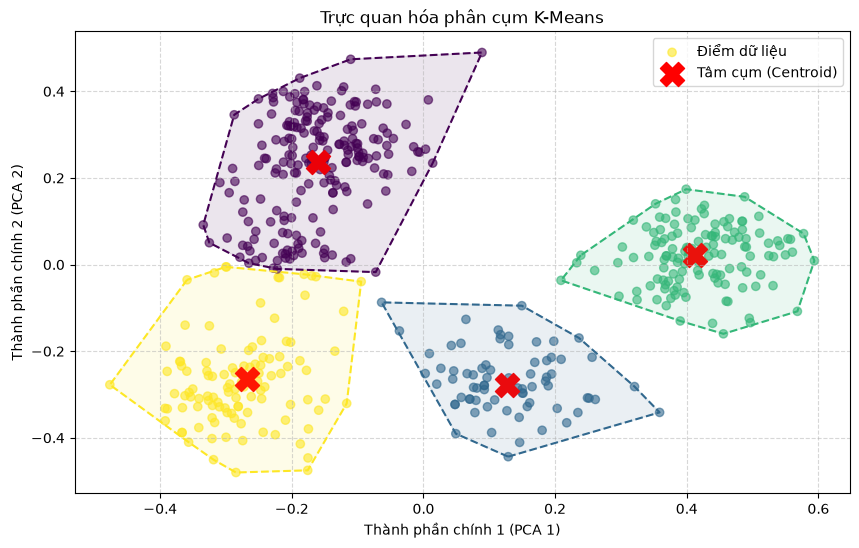

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull

# K-Means thường chạy trên nhiều chiều dữ liệu, ta dùng PCA để ép xuống 2D (2 chiều) cho dễ vẽ đồ thị
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test)

# Ép chiều cho các tâm cụm (centroids) tương ứng với dữ liệu
tam_cum_2d = pca.transform(k_means_final.cluster_centers_)

# Thiết lập kích thước khung hình
plt.figure(figsize=(10, 6))

# Vẽ các điểm dữ liệu kiểm thử, phân tách màu sắc (c) dựa trên nhãn vừa dự đoán
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=predict, cmap='viridis', alpha=0.6, label='Điểm dữ liệu')

# Vẽ nổi bật các tâm cụm bằng biểu tượng chữ 'X' màu đỏ
plt.scatter(tam_cum_2d[:, 0], tam_cum_2d[:, 1], s=300, c='red', marker='X', label='Tâm cụm (Centroid)')

# ----- Thêm Convex Hull cho từng cụm -----
colors = plt.cm.viridis(np.linspace(0, 1, len(set(predict))))

for cluster_id, color in zip(sorted(set(predict)), colors):
    # Lấy các điểm thuộc cụm hiện tại
    points = X_test_2d[predict == cluster_id]
    
    # Convex hull cần tối thiểu 3 điểm không thẳng hàng để vẽ được
    if len(points) < 3:
        continue
    
    hull = ConvexHull(points)
    
    # Nối các điểm biên của hull lại thành đường bao khép kín
    hull_points = points[hull.vertices]
    hull_points = np.vstack([hull_points, hull_points[0]])  # nối điểm cuối về điểm đầu
    
    plt.plot(hull_points[:, 0], hull_points[:, 1], '--', color=color, linewidth=1.5)
    plt.fill(hull_points[:, 0], hull_points[:, 1], color=color, alpha=0.1)

plt.title('Trực quan hóa phân cụm K-Means')
plt.xlabel('Thành phần chính 1 (PCA 1)')
plt.ylabel('Thành phần chính 2 (PCA 2)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()